In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [42]:
df = pd.read_csv('../data/raw/synthetic_fraud_dataset.csv')
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


# EDA

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [44]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


array([[<Axes: title={'center': 'transaction_id'}>,
        <Axes: title={'center': 'user_id'}>,
        <Axes: title={'center': 'amount'}>],
       [<Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'device_risk_score'}>,
        <Axes: title={'center': 'ip_risk_score'}>],
       [<Axes: title={'center': 'is_fraud'}>, <Axes: >, <Axes: >]],
      dtype=object)

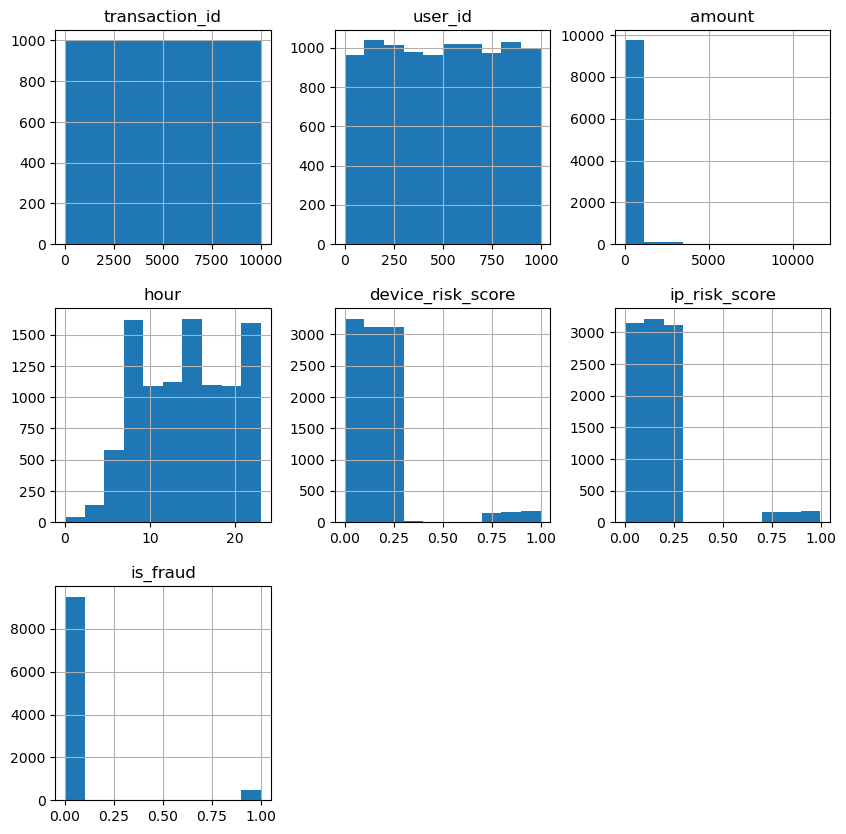

In [45]:
df.hist(figsize=(10,10))

In [46]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


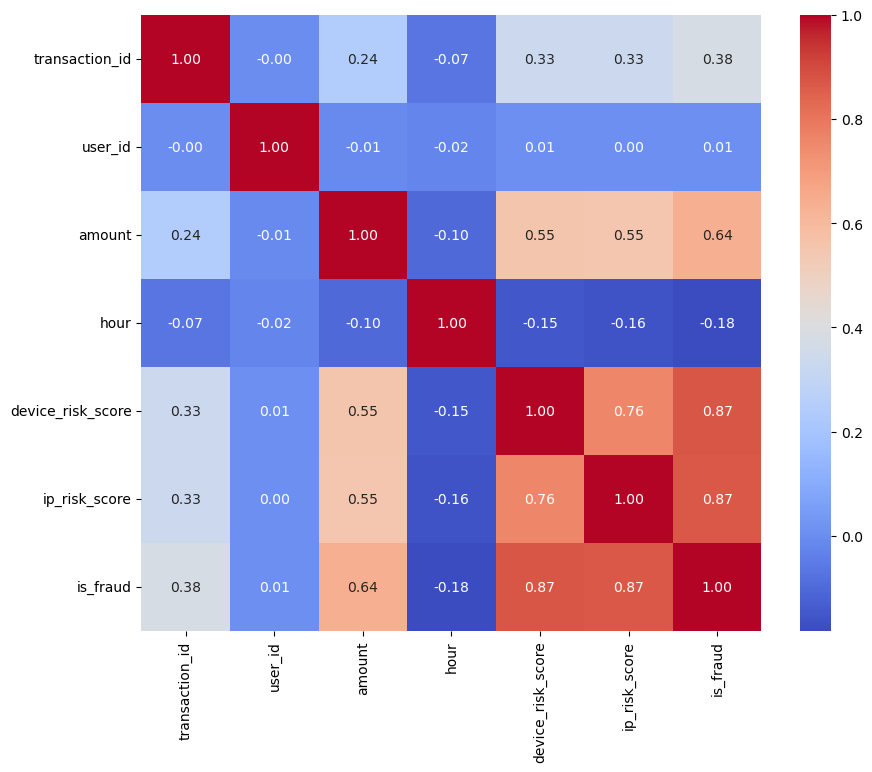

In [47]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [48]:
df.select_dtypes(include='object').nunique()

transaction_type     4
merchant_category    5
country              6
dtype: int64

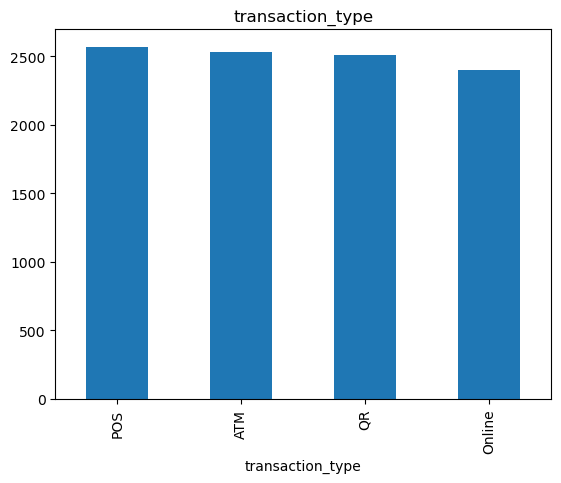

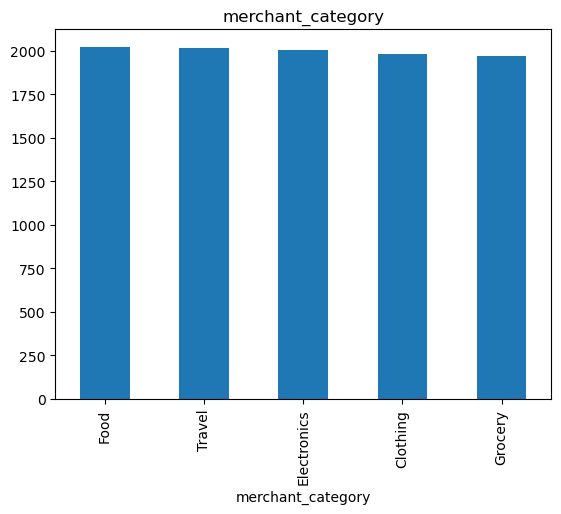

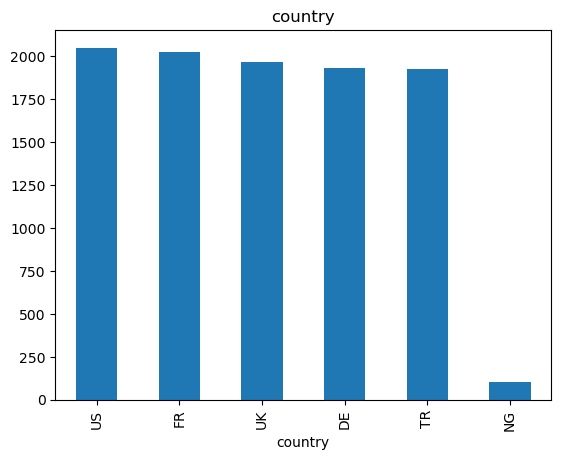

In [49]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

# **Funfact mengenai 'device_risk_score' dan 'ip_risk_score'**

Biasanya **`device_risk_score`** dan **`ip_risk_score`** bukan data mentah. Keduanya adalah **skor yang dihasilkan oleh sistem risk engine** berdasarkan banyak sinyal (features) lain. Sistem fraud modern hampir selalu punya modul seperti ini.

---

## 1. `device_risk_score`

Ini adalah skor yang menunjukkan **seberapa berisiko perangkat yang digunakan user**.

Skor dihitung dari **device fingerprinting**.

Contoh data yang dipakai:

```
device_id
browser type
OS version
screen resolution
timezone
language
cookies
canvas fingerprint
installed fonts
device model
```

### Contoh pola risiko

Beberapa kondisi yang menaikkan skor:

```
device baru yang belum pernah dipakai user
device yang dipakai oleh banyak akun
perangkat emulator
browser automation (selenium / bot)
perubahan device fingerprint mendadak
```

Contoh rule sederhana:

```
device pernah dipakai fraud → risk tinggi
device baru + transaksi besar → risk naik
device dipakai 10 akun → risk sangat tinggi
```

### Tools yang biasa dipakai

Beberapa sistem industri:

* **FingerprintJS**
* **ThreatMetrix**
* **Sift**
* **Riskified**
* **SEON**

Mereka menghasilkan **device reputation score**.

---

## 2. `ip_risk_score`

Ini adalah skor yang menunjukkan **seberapa berisiko alamat IP**.

IP dianalisis menggunakan **IP intelligence database**.

Contoh data yang digunakan:

```
IP reputation
VPN / proxy detection
TOR node
hosting provider
geolocation
IP blacklist
ASN (autonomous system)
```

### Contoh pola risiko

Kasus yang menaikkan skor:

```
IP berasal dari TOR
IP adalah public proxy
IP dari data center (AWS, OVH, DigitalOcean)
IP pernah dipakai fraud
IP lokasi tidak sesuai dengan user
```

Contoh rule sederhana:

```
TOR exit node → risk sangat tinggi
data center IP → risk tinggi
IP residential normal → risk rendah
```

### Provider yang sering dipakai

* **MaxMind**
* **IPQualityScore**
* **IP2Location**
* **Cloudflare IP intelligence**
* **SEON**

---

## 3. Bagaimana skor sebenarnya dihitung

Biasanya skor dibuat menggunakan **model ML atau rule engine**.

Contoh sederhana:

```
risk_score = 
    0.3 * device_new +
    0.2 * device_multi_account +
    0.3 * ip_proxy +
    0.2 * ip_blacklist
```

Outputnya biasanya:

```
0.0 – 1.0
atau
0 – 100
```

Semakin tinggi → semakin berisiko.

---

## 4. Kenapa dua fitur ini sangat kuat

Karena mereka sebenarnya **sudah merupakan hasil agregasi banyak sinyal**.

Misalnya:

```
device_risk_score
= hasil analisis 20 fitur device

ip_risk_score
= hasil analisis 15 fitur network
```

Jadi ketika kamu pakai skor ini sebagai fitur ML, model sebenarnya **sudah mendapat ringkasan informasi yang sangat kuat**.

---

## 5. Arsitektur fraud detection nyata

Di perusahaan fintech / bank biasanya pipeline seperti ini:

```
transaction data
      │
      ▼
device fingerprint system
IP intelligence system
      │
      ▼
device_risk_score
ip_risk_score
      │
      ▼
fraud ML model
      │
      ▼
approve / review / block
```

Model ML menjadi **layer kedua** setelah risk scoring.

---

## 6. Kenapa di dataset kamu korelasinya tinggi

Karena dataset kemungkinan dibuat seperti ini:

```
fraud_probability =
0.5 * device_risk_score +
0.4 * ip_risk_score +
noise kecil
```

Akibatnya model kamu mudah mencapai akurasi sangat tinggi.

# preprocessing

In [50]:
new_df = df.drop(columns=['transaction_id', 'user_id'])
new_df.head()

,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [51]:
# # kolom target
# X = new_df.drop(columns=['is_fraud'])
# y = new_df['is_fraud']

In [52]:
# kolom target
X = new_df.drop(columns=[
    'is_fraud',
    'device_risk_score',
    'ip_risk_score'
])
y = new_df['is_fraud']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
# Scaling numerik
# num_cols = ['amount', 'hour', 'device_risk_score', 'ip_risk_score']
num_cols = ['amount', 'hour']
cat_cols = ['transaction_type', 'merchant_category', 'country']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [55]:
# Encoding kategorikal
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse=False, drop='first', handle_unknown='ignore')

X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

encoded_train_df = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

encoded_test_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

c:\Users\Defanda\Anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [56]:
X_train = pd.concat([X_train[num_cols], encoded_train_df], axis=1)
X_test = pd.concat([X_test[num_cols], encoded_test_df], axis=1)

In [57]:
X_train.head()

,amount,hour,transaction_type_Online,transaction_type_POS,transaction_type_QR,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,country_FR,country_NG,country_TR,country_UK,country_US
1771,-0.149227,1.443858,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5149,-0.156333,-0.608700,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456,-0.181852,-1.168489,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1343,-0.237880,0.137685,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5957,-0.103719,-0.981892,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [58]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 1771 to 2207
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   amount                         8000 non-null   float64
 1   hour                           8000 non-null   float64
 2   transaction_type_Online        8000 non-null   float64
 3   transaction_type_POS           8000 non-null   float64
 4   transaction_type_QR            8000 non-null   float64
 5   merchant_category_Electronics  8000 non-null   float64
 6   merchant_category_Food         8000 non-null   float64
 7   merchant_category_Grocery      8000 non-null   float64
 8   merchant_category_Travel       8000 non-null   float64
 9   country_FR                     8000 non-null   float64
 10  country_NG                     8000 non-null   float64
 11  country_TR                     8000 non-null   float64
 12  country_UK                     8000 non-null   flo

# modelling

In [59]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [60]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1900
           1       0.96      0.89      0.92       100

    accuracy                           0.99      2000
   macro avg       0.98      0.94      0.96      2000
weighted avg       0.99      0.99      0.99      2000



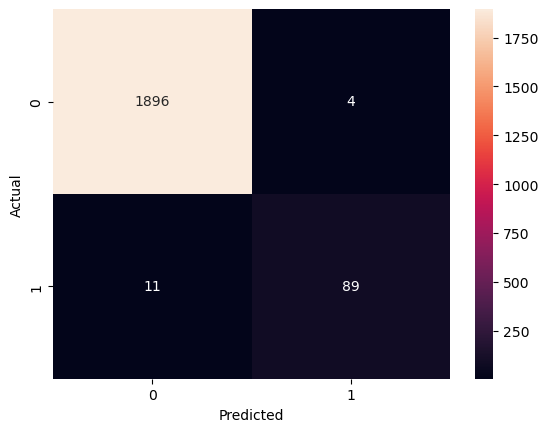

In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [63]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9980947368421053


In [64]:
pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

amount                           0.680042
hour                             0.194634
country_NG                       0.078603
country_FR                       0.005684
transaction_type_Online          0.004875
country_TR                       0.004768
country_US                       0.004325
transaction_type_POS             0.004310
merchant_category_Electronics    0.004144
transaction_type_QR              0.004133
merchant_category_Travel         0.003893
merchant_category_Grocery        0.003888
merchant_category_Food           0.003604
country_UK                       0.003098
dtype: float64